<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/03_1_Hernandez_Alvaro_TranferenciaAprendizaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio de transferencia de aprendizaje**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 1 de marzo de 2026




# **Indicaciones**

El archivo compartido representa un ejemplo de aplicación de transferencia de aprendizaje utilizando datos de imágenes histopatológicas. En el ejercicio que realizamos en clase trabajamos con imágenes de colon; sin embargo, para este problema deberán trabajar con imágenes histopatológicas de pulmón.<br>
En la siguiente liga podrán descargar la base de datos (que incluye tanto imágenes de pulmón como de colon): https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images <br>

La tarea es que implementen al menos tres redes neuronales de su preferencia aplicando transferencia de aprendizaje. Para ello deberán congelar las capas convolucionales del modelo base y entrenar únicamente las capas densas que se añadan en la etapa de clasificación.
Tomen en cuenta que la base de datos de imágenes de pulmón contiene tres clases:
* Tejido sano
* Adenocarcinoma
* Carcinoma de células escamosas

En las pruebas que realicen, se espera que obtengan al menos 96% de exactitud en la clasificación. En cada experimento deben presentar la matriz de confusión correspondiente a las predicciones en el conjunto de validación. <br>
El conjunto de validación debe representar el 15% de los datos.


In [1]:
# 1. Copiar el archivo desde tu Drive al almacenamiento local de Colab (/content/)
!cp "/content/drive/MyDrive/ClassFiles/archive.zip" "/content/"

# 2. Descomprimir el archivo de forma silenciosa (-q) en una carpeta llamada "datos_locales"
!unzip -q "/content/archive.zip" -d "/content/datos_locales/"

# 3. Borrar el .zip temporal local para liberar espacio en la memoria de Colab
!rm "/content/archive.zip"

In [2]:
# Librerías y funciones a utilizar

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from random import seed, randint
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# 🔧 Configurar GPU para asignar memoria de forma dinámica
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memoria de GPU configurada para crecimiento dinámico.")
    except RuntimeError as e:
        print("❌ Error al configurar memoria de GPU:", e)

In [4]:
directory = "/content/datos_locales/lung_colon_image_set/lung_image_sets"

generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.15,
    fill_mode='nearest')

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    validation_split=0.15
)

training_generator=generator.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    subset='training',
    seed=30,
)

val_generator=val_datagen.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    subset='validation',
    seed=30,
)

Found 12750 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.


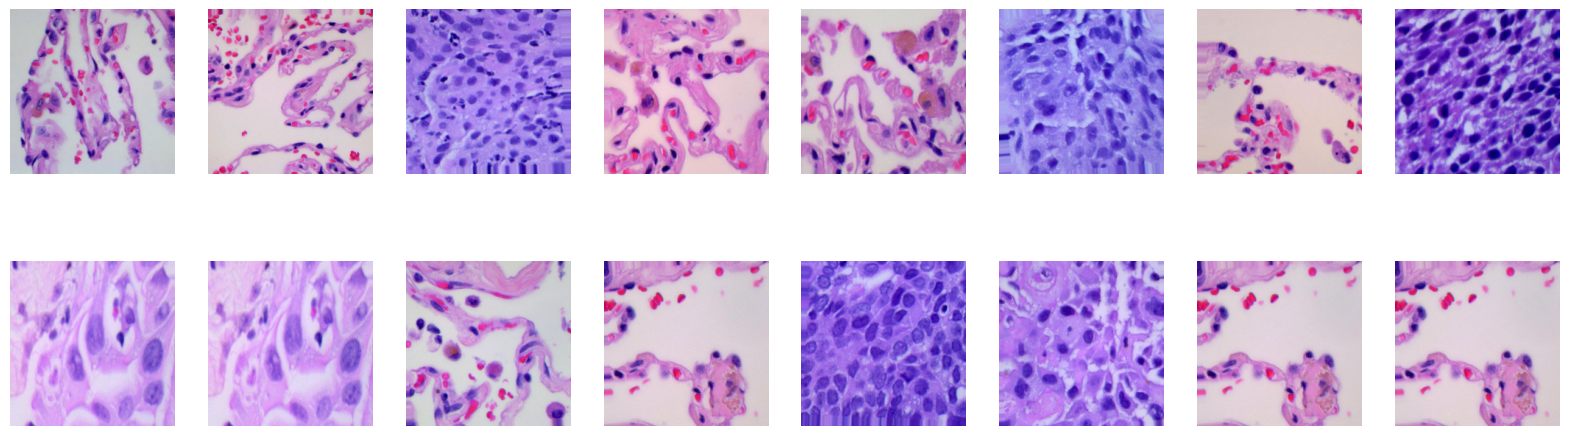

In [5]:
x,y=next(training_generator)

# Visualización de imágenes

plt.figure(1, figsize=(20,6))
plt.tight_layout()
for i in range(8):
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+1)
    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+9)
    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
plt.show()

## Primer modelo. **DenseNet121**

In [6]:
base_model_1 = DenseNet121(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False,
    pooling = "avg")

base_model_1.trainable = False

input_1 = tf.keras.layers.Input(shape=(224, 224, 3))

x1 = preprocess_densenet(input_1)
x1 = base_model_1(x1)
x1 = keras.layers.Dropout(0.2)(x1)
x1 = keras.layers.Dense(256, activation='relu')(x1)
x1 = keras.layers.BatchNormalization()(x1)
x1 = keras.layers.Dense(64, activation='relu')(x1)
x1 = keras.layers.BatchNormalization()(x1)
output_1 = keras.layers.Dense(3, activation='softmax')(x1)

model_1 = Model(inputs=input_1, outputs=output_1)

model_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'] )

print(model_1.summary())

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,317,827 (27.92 MB)

 Trainable params: 279,683 (1.07 MB)

 Non-trainable params: 7,038,144 (26.85 MB)

None


In [7]:
# Esta barrera corta el entrenamiento si el modelo ya no mejora después de 2 épocas
barrera = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Entrenamiento
history= model_1.fit(
    x=training_generator,
    batch_size=32,
    epochs=5,
    verbose=1,
    validation_data=val_generator,
    shuffle=True,
    callbacks=[barrera]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3295s 8s/step - accuracy: 0.7537 - loss: 0.5846 - val_accuracy: 0.9529 - val_loss: 0.1355
Epoch 2/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3259s 8s/step - accuracy: 0.9187 - loss: 0.2143 - val_accuracy: 0.9604 - val_loss: 0.1093
Epoch 3/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3215s 8s/step - accuracy: 0.9329 - loss: 0.1784 - val_accuracy: 0.9653 - val_loss: 0.0912
Epoch 4/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3212s 8s/step - accuracy: 0.9413 - loss: 0.1505 - val_accuracy: 0.9693 - val_loss: 0.0793
Epoch 5/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3212s 8s/step - accuracy: 0.9467 - loss: 0.1316 - val_accuracy: 0.9733 - val_loss: 0.0742


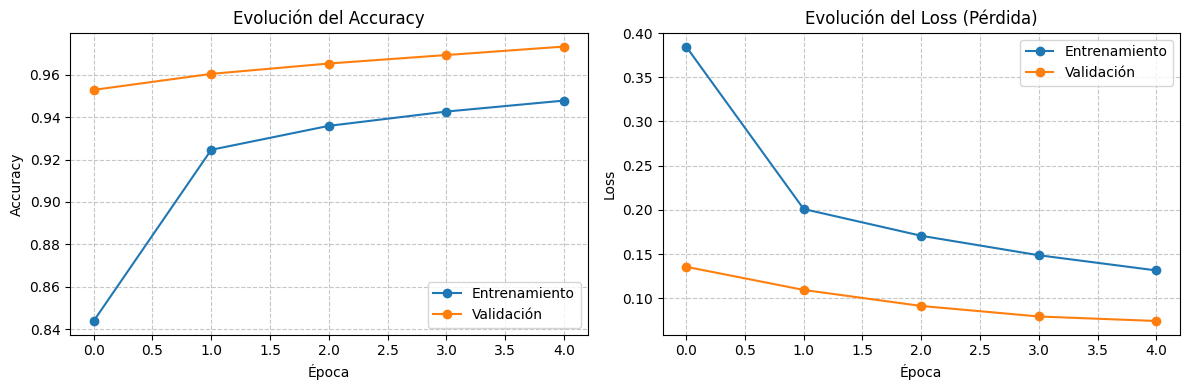

In [8]:
plt.figure(figsize=(12, 4))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', marker='o')
plt.plot(history.history['val_accuracy'], label='Validación', marker='o')
plt.title('Evolución del Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Época')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfica de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', marker='o')
plt.plot(history.history['val_loss'], label='Validación', marker='o')
plt.title('Evolución del Loss (Pérdida)')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Evaluación del primero modelo**

71/71 ━━━━━━━━━━━━━━━━━━━━ 462s 6s/step


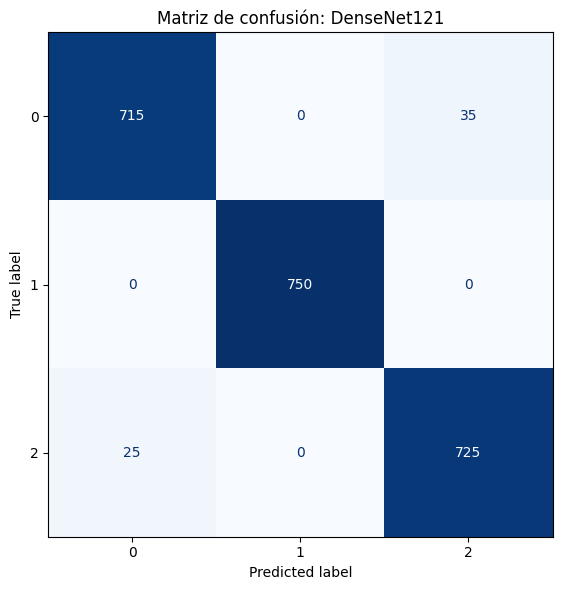


Reporte de clasificación DenseNet121:
              precision    recall  f1-score   support

           0     0.9662    0.9533    0.9597       750
           1     1.0000    1.0000    1.0000       750
           2     0.9539    0.9667    0.9603       750

    accuracy                         0.9733      2250
   macro avg     0.9734    0.9733    0.9733      2250
weighted avg     0.9734    0.9733    0.9733      2250



In [9]:
# Predicciones
val_generator.reset()

y_pred_probs_1 = model_1.predict(val_generator, verbose=1)
y_pred_1 = np.argmax(y_pred_probs_1, axis=1)
y_true = val_generator.classes

# Matriz de confusión
cm_1 = confusion_matrix(y_true, y_pred_1, labels=np.arange(3))
disp_1 = ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=np.arange(3))
fig, ax = plt.subplots(figsize=(6, 6))
disp_1.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Matriz de confusión: DenseNet121")
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación DenseNet121:")
print(classification_report(y_true, y_pred_1, digits=4))